In [23]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
df = pd.read_csv('../../../data/processed/final_dataset.csv')
df.head()

,sustainability_score,total_renewal_score_new,last_years_price,auto_renewal_score,status_scores,anchoring_score,tenure_scores,proforma_auto_renewal,proforma_world_pay_token,proforma_date,current_anchorings,payment_timeframe,registration_date,proforma_audit_status,renewal_score_at_release,proforma_approved_lists,tenure_years,prospect_renewal_date,starting_net,starting_vat,starting_gross,starting_membership_net,starting_package_net,starting_pqq_net,membership_net,package_net,pqqnet,total_amount,last_renewal,last_total_net_paid,last_connections,renewal_year,is_first_year,has_discount,discount_pct,price_increase_abs,price_increase_pct,price_increased_flag,band_ordinal,last_band_ordinal,band_changed,band_upgraded,band_downgraded,tenure_group_ordinal,anchor_group_ordinal,membership_status_ordinal,has_auto_renewal,has_world_pay_token,payment_method_bacs,payment_method_card,payment_method_cheque,payment_method_unknown,payment_method_world_pay,proforma_account_stage_membership_only,proforma_account_stage_published,proforma_account_stage_renewal_process,proforma_account_stage_retired,proforma_account_stage_suspended,proforma_account_stage_unknown,proforma_account_stage_vetting,churn,rc_14d_total_calls,rc_14d_inbound_calls,rc_14d_max_call_number,membership_renewal_decision,desire_to_cancel_encoded,customer_response_encoded,serious_complaint,other_complaint,complaint_count,discussion_on_price_increase,renewal_impact_due_to_price_increase,discount_or_waiver_requested,discount_offered,price_pressure_flag,price_range_discussed_flag,percentage_price_increase_mentioned,monetary_price_increase_mentioned,explicit_competitor_mention,explicit_switching_intent,mentioned_competitors,price_switching_mentioned,competitor_better_value,competitor_similar_value,competitor_better_service,competitor_cheaper,competitor_signal_count,competitor_threat_flag,agent_renewal_initiation,agent_flagged_membership_status_alert,agent_active_retention,call_reschedule_request,topic_by_customer,topic_by_agent,customer_asked_for_justification,rc_high_risk_call,rc_14d_outbound_calls,crm_sentiment_encoded,crm_dissatisfied_flag,crm_satisfied_flag,crm_contractor_sentiment_score,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_competitors_mentioned,crm_platform_issues_raised,crm_membership_overdue,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,crm_dts_or_ssip_mentioned,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_contractor_engagement,crm_customer_payment_intention,crm_agent_chased_contractor,crm_accreditation_issues,crm_agent_chase_count,crm_auto_renewal_status,crm_membership_level_ordinal,high_risk_email,emails_dissatisfaction_issue_count,engagement_score,sentiment_score_valid,email_count,cc_calls_14d_total_calls,cc_calls_14d_inbound_calls,cc_sentiment_encoded,cc_dissatisfied_flag,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,cc_urgency_getting_on_site,cc_chasing_response,cc_questionnaire_completion,cc_care_package_discussed,cc_external_consultant,cc_agent_cross_sell_attempt,cc_issues_within_questionnaire,sentiment_improved,sentiment_worsened,sentiment_change,cc_high_risk_call,cc_dissatisfaction_issue_count,pricing_pressure_flag,cc_care_package_assisted,cc_care_package_express,cc_care_package_not_discussed,cc_care_package_premier,cc_care_package_standard,cc_care_package_unknown,cc_call_initiated_by_agent,cc_call_initiated_by_customer,cc_call_initiated_by_not_relevant,cc_call_init

In [24]:
print(df.shape)
print(df["churn"].value_counts())

(113769, 175)
churn
0    101172
1     12597
Name: count, dtype: int64


In [25]:
# Calculate correlations with the 'churn' variable
correlations = df.corr(numeric_only=True)['churn'].sort_values(ascending=False)

print('Features correlated with churn (top 20 positive correlations):')
print(correlations.head(20))

print('\nFeatures correlated with churn (top 20 negative correlations):')
print(correlations.tail(20))

Features correlated with churn (top 20 positive correlations):
churn                                     1.000000
payment_method_unknown                    0.768344
discount_pct                              0.311491
has_discount                              0.266269
proforma_account_stage_membership_only    0.244535
crm_contractor_suggested_leave            0.224022
high_risk_email                           0.195712
price_increased_flag                      0.127737
crm_negative_customer_experience          0.117780
crm_financial_hardship_mentioned          0.116086
emails_dissatisfaction_issue_count        0.104557
is_first_year                             0.103514
crm_dissatisfied_flag                     0.102879
crm_auto_renewal_status                   0.097975
proforma_account_stage_vetting            0.094106
payment_timeframe                         0.088996
crm_agent_chase_count                     0.080012
price_increase_abs                        0.072205
has_email          

In [26]:
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,sustainability_score,total_renewal_score_new,last_years_price,auto_renewal_score,status_scores,anchoring_score,tenure_scores,proforma_auto_renewal,proforma_world_pay_token,current_anchorings,payment_timeframe,renewal_score_at_release,proforma_approved_lists,tenure_years,starting_net,starting_vat,starting_gross,starting_membership_net,starting_package_net,starting_pqq_net,membership_net,package_net,pqqnet,total_amount,last_total_net_paid,last_connections,renewal_year,is_first_year,has_discount,discount_pct,price_increase_abs,price_increase_pct,price_increased_flag,band_ordinal,last_band_ordinal,band_changed,band_upgraded,band_downgraded,tenure_group_ordinal,anchor_group_ordinal,membership_status_ordinal,has_auto_renewal,has_world_pay_token,payment_method_bacs,payment_method_card,payment_method_cheque,payment_method_unknown,payment_method_world_pay,proforma_account_stage_membership_only,proforma_account_stage_published,proforma_account_stage_renewal_process,proforma_account_stage_retired,proforma_account_stage_suspended,proforma_account_stage_unknown,proforma_account_stage_vetting,churn,rc_14d_total_calls,rc_14d_inbound_calls,rc_14d_max_call_number,membership_renewal_decision,desire_to_cancel_encoded,customer_response_encoded,serious_complaint,other_complaint,complaint_count,discussion_on_price_increase,renewal_impact_due_to_price_increase,discount_or_waiver_requested,discount_offered,price_pressure_flag,price_range_discussed_flag,percentage_price_increase_mentioned,monetary_price_increase_mentioned,explicit_competitor_mention,explicit_switching_intent,mentioned_competitors,price_switching_mentioned,competitor_better_value,competitor_similar_value,competitor_better_service,competitor_cheaper,competitor_signal_count,competitor_threat_flag,agent_renewal_initiation,agent_flagged_membership_status_alert,agent_active_retention,call_reschedule_request,topic_by_customer,topic_by_agent,customer_asked_for_justification,rc_high_risk_call,rc_14d_outbound_calls,crm_sentiment_encoded,crm_dissatisfied_flag,crm_satisfied_flag,crm_contractor_sentiment_score,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_competitors_mentioned,crm_platform_issues_raised,crm_membership_overdue,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,crm_dts_or_ssip_mentioned,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_contractor_engagement,crm_customer_payment_intention,crm_agent_chased_contractor,crm_accreditation_issues,crm_agent_chase_count,crm_auto_renewal_status,crm_membership_level_ordinal,high_risk_email,emails_dissatisfaction_issue_count,engagement_score,sentiment_score_valid,email_count,cc_calls_14d_total_calls,cc_calls_14d_inbound_calls,cc_sentiment_encoded,cc_dissatisfied_flag,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,cc_urgency_getting_on_site,cc_chasing_response,cc_questionnaire_completion,cc_care_package_discussed,cc_external_consultant,cc_agent_cross_sell_attempt,cc_issues_within_questionnaire,sentiment_improved,sentiment_worsened,sentiment_change,cc_high_risk_call,cc_dissatisfaction_issue_count,pricing_pressure_flag,cc_care_package_assisted,cc_care_package_express,cc_care_package_not_discussed,cc_care_package_premier,cc_care_package_standard,cc_care_package_unknown,cc_call_initiated_by_agent,cc_call_initiated_by_customer,cc_call_initiated_by_not_relevant,cc_call_initiated_by_unknown,cc_calls_14d_outbound_calls,has_renewal_call,has_email,has_cc_call
count

In [27]:
print('\nMissing Values:')
display(df.isnull().sum())


Missing Values:


sustainability_score            0
total_renewal_score_new         0
last_years_price                0
auto_renewal_score              0
status_scores                   0
                               ..
cc_call_initiated_by_unknown    0
cc_calls_14d_outbound_calls     0
has_renewal_call                0
has_email                       0
has_cc_call                     0
Length: 175, dtype: int64

**HYPOTHESIS TESTING**

### Hypothesis Test 1: Discount Percentage

**H0:** The mean `discount_pct` is the same for churned and non-churned customers.

**H1:** The mean `discount_pct` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

T-statistic: 61.340
P-value: 0.000e+00


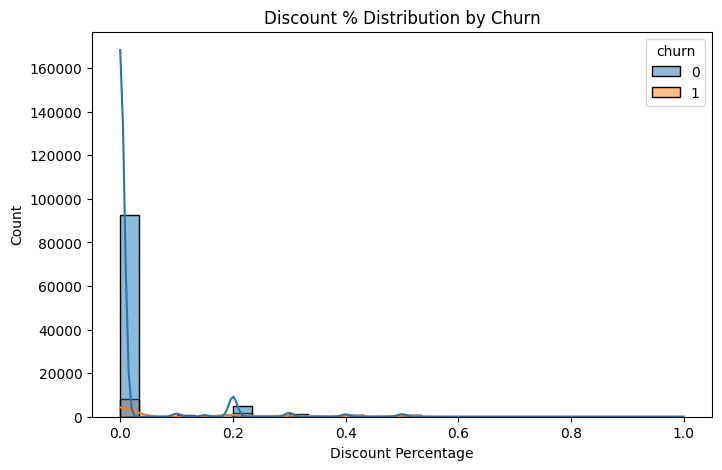

In [28]:
discount_churn = df[df['churn'] == 1]['discount_pct']
discount_no_churn = df[df['churn'] == 0]['discount_pct']

t_stat, p_value = ttest_ind(discount_churn, discount_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='discount_pct',
    hue='churn',
    bins=30,
    kde=True
)

plt.title("Discount % Distribution by Churn")
plt.xlabel("Discount Percentage")
plt.ylabel("Count")
plt.show()

### Inference for Hypothesis Test 1

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `discount_pct` between churned and non-churned customers.

### Hypothesis Test 2: Tenure Years

**H0:** The mean `tenure_years` is the same for churned and non-churned customers.

**H1:** The mean `tenure_years` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

T-statistic: -67.037
P-value: 0.000e+00


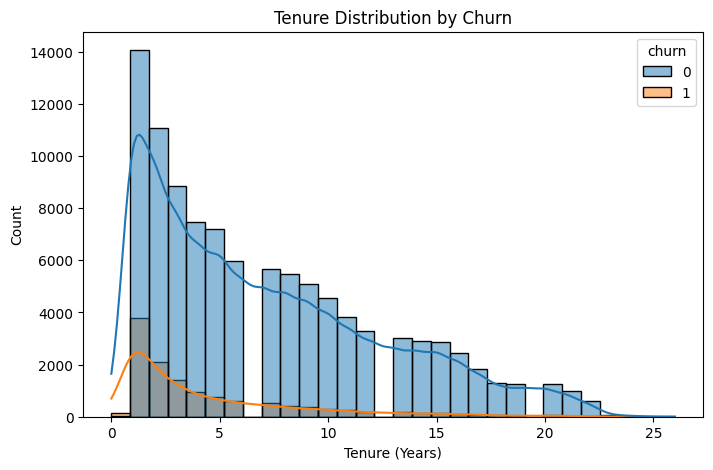

In [29]:
tenure_churn = df[df['churn'] == 1]['tenure_years']
tenure_no_churn = df[df['churn'] == 0]['tenure_years']

t_stat, p_value = ttest_ind(tenure_churn, tenure_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='tenure_years',
    hue='churn',
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Years)")
plt.ylabel("Count")
plt.show()

### Inference for Hypothesis Test 2

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `tenure_years` between churned and non-churned customers.

### Hypothesis Test 3: Total Amount Paid

**H0:** The mean `total_amount` is the same for churned and non-churned customers.

**H1:** The mean `total_amount` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

T-statistic: -60.012
P-value: 0.000e+00


C:\Users\Bacon\AppData\Local\Temp\ipykernel_4056\2448186220.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_amount_log'] = np.log1p(df['total_amount'])


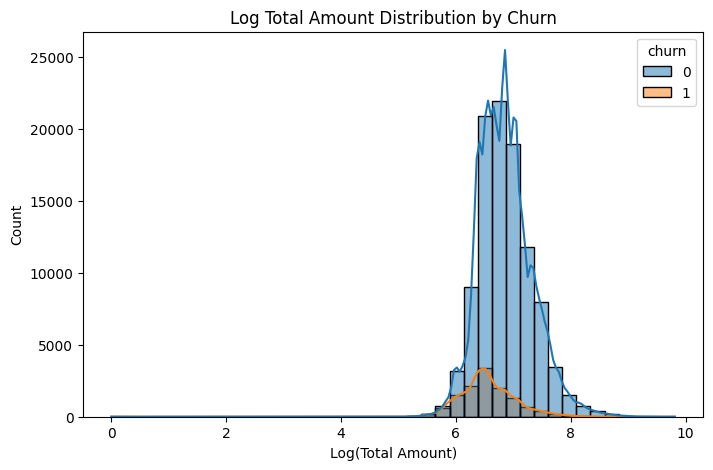

In [30]:
total_amount_churn = df[df['churn'] == 1]['total_amount']
total_amount_no_churn = df[df['churn'] == 0]['total_amount']

t_stat, p_value = ttest_ind(total_amount_churn, total_amount_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

df['total_amount_log'] = np.log1p(df['total_amount'])

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='total_amount_log',
    hue='churn',
    bins=40,
    kde=True
)

plt.title("Log Total Amount Distribution by Churn")
plt.xlabel("Log(Total Amount)")
plt.show()

### Inference for Hypothesis Test 3

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `total_amount` between churned and non-churned customers.

### Hypothesis Test 4: Sustainability Score

**H0:** The mean `sustainability_score` is the same for churned and non-churned customers.

**H1:** The mean `sustainability_score` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

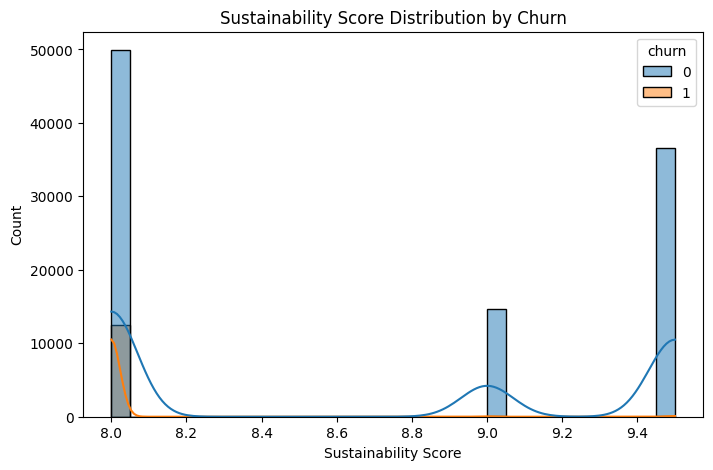

In [ ]:
sustainability_churn = df[df['churn'] == 1]['sustainability_score']
sustainability_no_churn = df[df['churn'] == 0]['sustainability_score']

t_stat, p_value = ttest_ind(sustainability_churn, sustainability_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='sustainability_score',
    hue='churn',
    bins=30,
    kde=True
)

plt.title("Sustainability Score Distribution by Churn")
plt.xlabel("Sustainability Score")
plt.ylabel("Count")
plt.show()

### Inference for Hypothesis Test 4

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `sustainability_score` between churned and non-churned customers.

### Hypothesis Test 5: Payment Method (Unknown) and Churn

**H0:** `payment_method_unknown` is independent of `churn`.

**H1:** `payment_method_unknown` is associated with `churn`.

**Test:** Chi-squared test of independence.

Chi-squared statistic: 67154.032
P-value: 0.000e+00


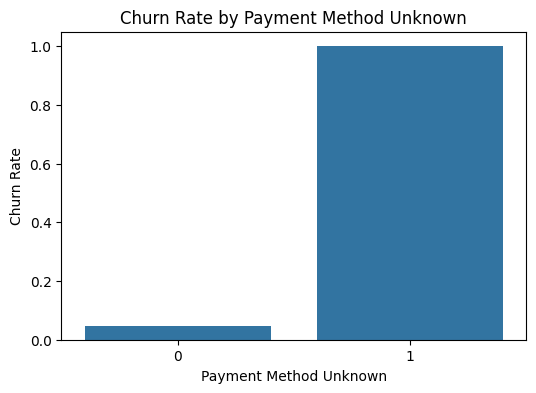

In [39]:
contingency_table = pd.crosstab(df['payment_method_unknown'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

churn_rate = df.groupby('payment_method_unknown')['churn'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='payment_method_unknown', y='churn', data=churn_rate)

plt.title("Churn Rate by Payment Method Unknown")
plt.xlabel("Payment Method Unknown")
plt.ylabel("Churn Rate")
plt.show()

### Inference for Hypothesis Test 5

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `payment_method_unknown` and `churn`.

### Hypothesis Test 6: Desire to Cancel and Churn

**H0:** `desire_to_cancel_encoded` is independent of `churn`.

**H1:** `desire_to_cancel_encoded` is associated with `churn`.

**Test:** Chi-squared test of independence.

Chi-squared statistic: 83.971
P-value: 5.021e-20


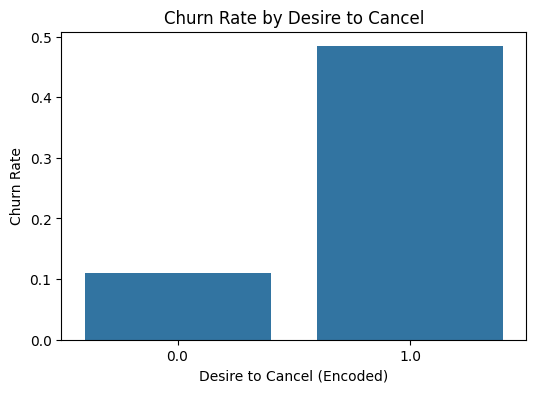

In [40]:
contingency_table = pd.crosstab(df['desire_to_cancel_encoded'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

churn_rate = df.groupby('desire_to_cancel_encoded')['churn'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='desire_to_cancel_encoded', y='churn', data=churn_rate)

plt.title("Churn Rate by Desire to Cancel")
plt.xlabel("Desire to Cancel (Encoded)")
plt.ylabel("Churn Rate")
plt.show()

### Inference for Hypothesis Test 6

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `desire_to_cancel_encoded` and `churn`.

### Hypothesis Test 7: High Risk Email and Churn

**H0:** `high_risk_email` is independent of `churn`.

**H1:** `high_risk_email` is associated with `churn`.

**Test:** Chi-squared test of independence.

Chi-squared statistic: 4354.384
P-value: 0.000e+00


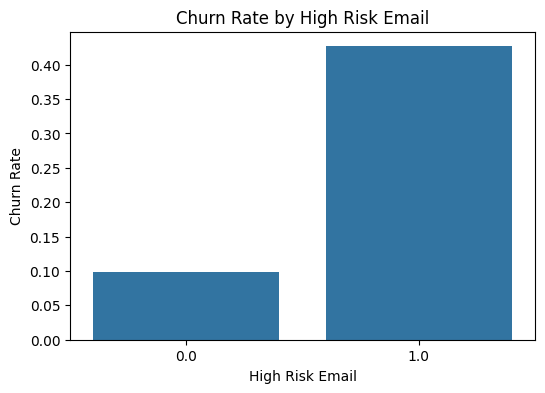

In [41]:
contingency_table = pd.crosstab(df['high_risk_email'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

churn_rate = df.groupby('high_risk_email')['churn'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='high_risk_email', y='churn', data=churn_rate)

plt.title("Churn Rate by High Risk Email")
plt.xlabel("High Risk Email")
plt.ylabel("Churn Rate")
plt.show()

### Inference for Hypothesis Test 7

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `high_risk_email` and `churn`.

### Hypothesis Test 8: Customer Dissatisfaction and Churn

**H0:** `crm_dissatisfied_flag` is independent of `churn`.

**H1:** `crm_dissatisfied_flag` is associated with `churn`.

**Test:** Chi-squared test of independence.

Chi-squared statistic: 1201.209
P-value: 3.330e-263


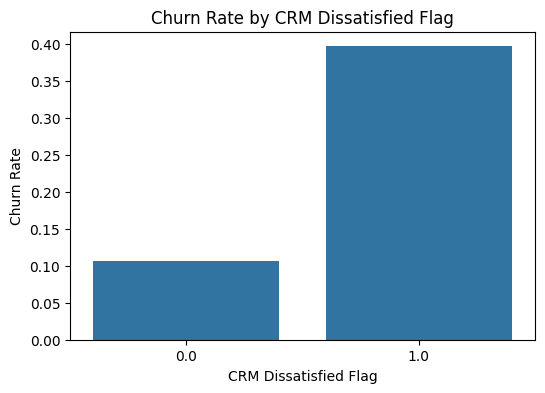

In [42]:
contingency_table = pd.crosstab(df['crm_dissatisfied_flag'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

churn_rate = df.groupby('crm_dissatisfied_flag')['churn'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='crm_dissatisfied_flag', y='churn', data=churn_rate)

plt.title("Churn Rate by CRM Dissatisfied Flag")
plt.xlabel("CRM Dissatisfied Flag")
plt.ylabel("Churn Rate")
plt.show()

### Inference for Hypothesis Test 8

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `crm_dissatisfied_flag` and `churn`.

### Hypothesis Test 9: Price Increase Impact and Churn

**H0:** `price_increased_flag` is independent of `churn`.

**H1:** `price_increased_flag` is associated with `churn`.

**Test:** Chi-squared test of independence.

Chi-squared statistic: 1855.307
P-value: 0.000e+00


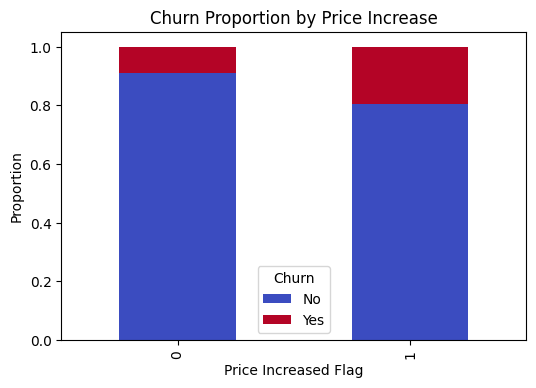

In [ ]:
contingency_table = pd.crosstab(df['price_increased_flag'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

ct_percent = contingency_table.div(contingency_table.sum(axis=1), axis=0)
ct_percent.plot(kind='bar', stacked=True, figsize=(6,4), colormap='coolwarm')

plt.title("Churn Proportion by Price Increase")
plt.xlabel("Price Increased Flag")
plt.ylabel("Proportion")
plt.legend(title="Churn", labels=["No", "Yes"])

### Inference for Hypothesis Test 9

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `price_increased_flag` and `churn`.

### Hypothesis Test 10: Auto Renewal and Churn

**H0:** `has_auto_renewal` is independent of `churn`.

**H1:** `has_auto_renewal` is associated with `churn`.

**Test:** Chi-squared test of independence.

Chi-squared statistic: 2405.615
P-value: 0.000e+00


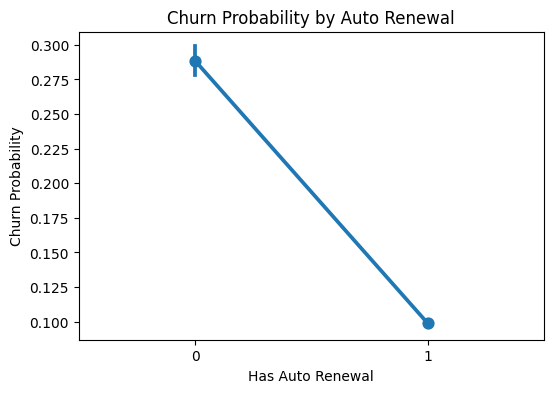

In [44]:
contingency_table = pd.crosstab(df['has_auto_renewal'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

plt.figure(figsize=(6,4))

sns.pointplot(
    x='has_auto_renewal',
    y='churn',
    data=df,
    errorbar=('ci', 95)
)

plt.title("Churn Probability by Auto Renewal")
plt.xlabel("Has Auto Renewal")
plt.ylabel("Churn Probability")
plt.show()

### Inference for Hypothesis Test 10

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `has_auto_renewal` and `churn`.